<a href="https://colab.research.google.com/github/JoaoIvo15/Regressao-Multipla-Energy-Efficiency/blob/main/notebooks/02_modelagem_MRLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Modelagem por Regressão Linear Múltipla

**Dataset:** Energy Efficiency
**Disciplina:** Modelagem Estatística


## Objetivo

Construir e avaliar modelos de **Regressão Linear Múltipla** para as variáveis resposta **Y1 (Heating Load)** e **Y2 (Cooling Load)**, utilizando como base os resultados obtidos na análise exploratória.

A etapa de modelagem contempla a especificação do modelo, estimação dos parâmetros, inferência estatística e investigação da multicolinearidade entre os preditores.


## Preparação do Ambiente

In [302]:
# Bibliotecas para modelagem e análise estatística

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Fonte do dataset no GitHub

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "JoaoIvo15/Regressao-Multipla-Energy-Efficiency/"
    "main/data/raw/ENB2012_data.xlsx"
)

# Carregamento da base original

df = pd.read_excel(DATA_URL)

## 1. Preparação para a modelagem

A modelagem será realizada a partir da base original, preservando os dados utilizados na análise exploratória.

As variáveis **X1, X2, X3, X4, X5 e X7** serão inicialmente representadas quantitativamente. As variáveis **X6 (Orientation)** e **X8 (Glazing Area Distribution)**, por representarem categorias codificadas numericamente, serão convertidas em variáveis indicadoras.

A transformação será realizada em uma cópia da base, mantendo o objeto `df` inalterado.


In [303]:
# Cópia da base original

df_model = df.copy()

In [304]:
# Conversão de X6 e X8 em variáveis indicadoras

df_model = pd.get_dummies(
    df_model,
    columns=["X6", "X8"],
    drop_first=True,
    dtype=int
)

display(df_model.head())

,X1,X2,X3,X4,X5,X7,Y1,Y2,X6_3,X6_4,X6_5,X8_1,X8_2,X8_3,X8_4,X8_5
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,0,0,0,0,0,0,0
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,1,0,0,0,0,0,0,0
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,1,0,0,0,0,0,0
3,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,0,1,0,0,0,0,0
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84,28.28,0,0,0,0,0,0,0,0


In [305]:
# Variáveis disponíveis na base de modelagem

df_model.columns.tolist()

['X1',
 'X2',
 'X3',
 'X4',
 'X5',
 'X7',
 'Y1',
 'Y2',
 'X6_3',
 'X6_4',
 'X6_5',
 'X8_1',
 'X8_2',
 'X8_3',
 'X8_4',
 'X8_5']

## 2. Dependência Linear entre os Preditores

Antes da estimação dos modelos de Regressão Linear Múltipla, é necessário verificar se as variáveis explicativas fornecem informações independentes entre si. Essa análise é particularmente importante porque a presença de dependência linear entre os preditores pode comprometer a identificação dos coeficientes do modelo.

Na análise exploratória realizada no Notebook 01, foram observadas associações muito fortes entre algumas variáveis geométricas do conjunto de dados. Entre elas, destacou-se uma relação exata entre X2, X3 e X4. Diferentemente de uma correlação apenas elevada, essa relação representa uma dependência linear determinística existente em todas as observações da base.

Nesta seção, essa dependência será demonstrada algebricamente e computacionalmente, e serão discutidas suas consequências para a estimação por Mínimos Quadrados Ordinários.


### 2.1 Relação determinística entre X2, X3 e X4

Durante a análise das variáveis explicativas, foi identificada a seguinte relação:

$$
X_2 = X_3 + 2X_4
$$

Essa igualdade indica que o valor de X2 pode ser determinado exatamente a partir de X3 e X4. Portanto, uma das três variáveis não acrescenta uma nova dimensão de informação quando as outras duas já estão presentes.

Essa característica é diferente de uma associação linear forte, na qual os valores das variáveis apenas tendem a acompanhar uma determinada relação. Neste caso, a relação é exata: não há erro ou variação residual entre os dois lados da igualdade.

Como consequência, as colunas correspondentes a X2, X3 e X4 não são linearmente independentes.


In [306]:
relation_error = df["X2"] - df["X3"] - 2 * df["X4"]

print("Maior erro absoluto:")
print(relation_error.abs().max())

Maior erro absoluto:
0.0


In [307]:
relation_holds = np.allclose(
    df["X2"],
    df["X3"] + 2 * df["X4"]
)

print("X2 = X3 + 2*X4 válida para toda a base:", relation_holds)

X2 = X3 + 2*X4 válida para toda a base: True


### 2.2 Definição formal de dependência linear

Um conjunto de variáveis é linearmente dependente quando existe uma combinação linear não trivial entre elas que resulta na variável nula.

A relação encontrada pode ser reescrita como:

$$
X_2 - X_3 - 2X_4 = 0
$$

Assim, existe uma combinação linear dos três preditores que é identicamente igual a zero em todas as observações.

Em termos de um vetor de coeficientes,

$$
\begin{bmatrix}
1\\
-1\\
-2
\end{bmatrix},
$$

tem-se:

$$
[X_2\;\;X_3\;\;X_4]
\begin{bmatrix}
1\\
-1\\
-2
\end{bmatrix}
=
0.
$$

Como esse vetor de coeficientes não é o vetor nulo, a combinação caracteriza uma dependência linear exata entre as variáveis.


In [308]:
X_geometry = df[["X2", "X3", "X4"]].to_numpy()

dependence_vector = np.array([1, -1, -2])

dependence_result = X_geometry @ dependence_vector

print("Maior valor absoluto da combinação linear:")
print(np.abs(dependence_result).max())

Maior valor absoluto da combinação linear:
0.0


### 2.3 Demonstração pelo posto da matriz

Outra forma de verificar a dependência linear é analisar o posto da matriz formada pelas variáveis X2, X3 e X4.

Se as três colunas fossem linearmente independentes, o posto da matriz seria igual a 3. Entretanto, como uma delas pode ser obtida exatamente a partir das outras duas, espera-se um posto igual a 2.


In [309]:
X_geometry = df[["X2", "X3", "X4"]].to_numpy()

rank_geometry = np.linalg.matrix_rank(X_geometry)

print("Número de colunas:", X_geometry.shape[1])
print("Posto da matriz [X2, X3, X4]:", rank_geometry)

Número de colunas: 3
Posto da matriz [X2, X3, X4]: 2


O posto da matriz é igual a 2, enquanto existem 3 colunas. Portanto, as colunas não são linearmente independentes, confirmando computacionalmente a dependência identificada anteriormente.

O resultado não decorre de arredondamentos ou de uma aproximação numérica entre as variáveis, mas da relação determinística já demonstrada:

$$
X_2-X_3-2X_4=0.
$$


### 2.4 Consequência para a estimação do MRLM

Considere inicialmente um modelo que utilize simultaneamente X2, X3 e X4:

$$
Y_i = \beta_0+\beta_2X_{2i}+\beta_3X_{3i}+\beta_4X_{4i}+\varepsilon_i.
$$

Em forma matricial:

$$
\mathbf{Y}=\mathbf{X}\boldsymbol{\beta}+\boldsymbol{\varepsilon},
$$

em que a matriz de projeto contém as colunas correspondentes ao intercepto, X2, X3 e X4:

$$
\mathbf{X}
=
\begin{bmatrix}
1 & X_2 & X_3 & X_4
\end{bmatrix}.
$$

Como existe a relação

$$
X_2-X_3-2X_4=0,
$$

as quatro colunas da matriz de projeto não são linearmente independentes. Consequentemente, a matriz não possui posto completo.


In [310]:
X_geometry_intercept = np.column_stack([
    np.ones(len(df)),
    df["X2"].to_numpy(),
    df["X3"].to_numpy(),
    df["X4"].to_numpy()
])

rank_design = np.linalg.matrix_rank(X_geometry_intercept)

print("Número de colunas da matriz de projeto:", X_geometry_intercept.shape[1])
print("Posto da matriz de projeto:", rank_design)

Número de colunas da matriz de projeto: 4
Posto da matriz de projeto: 3


A matriz de projeto possui quatro colunas, mas seu posto é igual a 3. Portanto, não possui posto completo.

A inclusão do intercepto não é responsável pela dependência. A relação linear já existe entre as colunas X2, X3 e X4 e permanece presente quando a coluna de 1's é adicionada.


Na estimação por Mínimos Quadrados Ordinários, o estimador dos coeficientes é usualmente escrito como

$$
\hat{\boldsymbol{\beta}}
=
(\mathbf{X}^{T}\mathbf{X})^{-1}
\mathbf{X}^{T}\mathbf{Y}.
$$

Para que essa expressão produza uma solução única por meio da inversa, a matriz de projeto deve possuir posto completo. Quando existe dependência linear exata entre suas colunas, $\mathbf{X}^{T}\mathbf{X}$ é singular e não possui inversa ordinária.

Assim, os coeficientes associados a X2, X3 e X4 não podem ser identificados individualmente de forma única quando as três variáveis são incluídas simultaneamente no modelo.


A consequência também pode ser observada diretamente substituindo a relação

$$
X_2=X_3+2X_4
$$

no modelo:

$$
Y
=
\beta_0+\beta_2X_2+\beta_3X_3+\beta_4X_4+\varepsilon.
$$

Substituindo X2:

$$
Y
=
\beta_0+\beta_2(X_3+2X_4)+\beta_3X_3+\beta_4X_4+\varepsilon.
$$

Agrupando os termos:

$$
Y
=
\beta_0
+
(\beta_2+\beta_3)X_3
+
(2\beta_2+\beta_4)X_4
+
\varepsilon.
$$

Portanto, os dados identificam apenas as combinações

$$
\beta_2+\beta_3
$$

e

$$
2\beta_2+\beta_4,
$$

e não os três coeficientes $\beta_2,\beta_3,\beta_4$ individualmente.

Esse resultado fornece uma interpretação direta para a perda de identificabilidade: diferentes combinações dos coeficientes podem produzir exatamente o mesmo valor ajustado para todas as observações.


### 2.5 Dependência perfeita e multicolinearidade forte

É importante distinguir a dependência linear exata identificada entre X2, X3 e X4 de uma situação de multicolinearidade elevada, mas não perfeita.

Na multicolinearidade forte, os preditores apresentam associação linear elevada, porém ainda existe informação suficiente para que a matriz de projeto mantenha posto completo. Nesse caso, os coeficientes podem ser estimados, embora suas estimativas possam apresentar maior variabilidade, erros-padrão elevados e maior sensibilidade às alterações nos dados ou na especificação do modelo.

Na dependência linear perfeita, por outro lado, existe uma combinação linear exata entre os preditores. A matriz de projeto deixa de possuir posto completo e os coeficientes individuais das variáveis envolvidas não são identificáveis de forma única.

Portanto, a relação

$$
X_2=X_3+2X_4
$$

não representa apenas uma correlação elevada: trata-se de uma dependência linear determinística.


### 2.6 Implicação para a especificação do modelo

A análise realizada mostrou que X2, X3 e X4 não podem ser incluídas simultaneamente como preditores independentes em um modelo de Regressão Linear Múltipla, pois apresentam dependência linear perfeita.

Consequentemente, a especificação dos modelos deverá considerar essa estrutura. Será necessário definir uma representação do conjunto de variáveis geométricas que preserve a informação relevante da base sem introduzir dependência linear perfeita na matriz de projeto.

A escolha das variáveis que permanecerão na especificação não será feita apenas com base na magnitude das correlações observadas. Também serão considerados o significado das variáveis, a interpretação dos coeficientes e o objetivo do modelo.

Com essa questão identificada, a próxima etapa consiste em definir formalmente o conjunto de preditores e a representação das variáveis categóricas para a estimação dos modelos.


### 2.7 Definição do conjunto inicial de preditores

A dependência linear perfeita identificada entre X2, X3 e X4 impede que essas três variáveis sejam utilizadas simultaneamente como preditores independentes em um mesmo modelo de Regressão Linear Múltipla.

Para a especificação inicial, optou-se por manter X3 (Wall Area) e X4 (Roof Area), excluindo X2 (Surface Area). Essa escolha permite representar separadamente as duas características geométricas que determinam X2 por meio da relação

$$
X_2 = X_3 + 2X_4.
$$

A exclusão de X2, portanto, não representa uma conclusão de que essa variável seja irrelevante para as variáveis resposta. Trata-se de uma decisão de especificação necessária para evitar dependência linear perfeita entre os preditores.

Dessa forma, o conjunto inicial de variáveis explicativas é composto por X1, X3, X4, X5, X6, X7 e X8. As variáveis X6 e X8 são representadas no modelo por variáveis indicadoras, conforme definido na etapa de preparação dos dados.

Esse conjunto será utilizado como referência para a investigação da multicolinearidade e para a construção dos modelos iniciais.


In [311]:
predictors_initial = [
    "X1",
    "X3",
    "X4",
    "X5",
    "X6",
    "X7",
    "X8"
]

print("Preditores do conjunto inicial:")
print(predictors_initial)

Preditores do conjunto inicial:
['X1', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']


## 3. Diagnóstico de Multicolinearidade

A identificação da dependência linear perfeita entre X2, X3 e X4 não elimina a possibilidade de existência de outras relações lineares fortes entre os preditores. Embora essas relações não necessariamente impeçam a estimação do modelo, podem aumentar a variabilidade das estimativas dos coeficientes e dificultar sua interpretação.

Nesta etapa, investiga-se a presença de multicolinearidade entre as variáveis explicativas que compõem o conjunto inicial de preditores. Inicialmente, são analisadas as correlações entre as variáveis quantitativas.


In [312]:
quantitative_predictors_initial = [
    "X1",
    "X3",
    "X4",
    "X5",
    "X7"
]

correlation_matrix = df_model[
    quantitative_predictors_initial
].corr()

correlation_matrix

,X1,X3,X4,X5,X7
X1,1.000000e+00,-2.037817e-01,-8.688234e-01,8.277473e-01,-2.960552e-15
X3,-2.037817e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-8.567455e-17
X4,-8.688234e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-1.759011e-15
X5,8.277473e-01,2.809757e-01,-9.725122e-01,1.000000e+00,1.489134e-17
X7,-2.960552e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,1.000000e+00


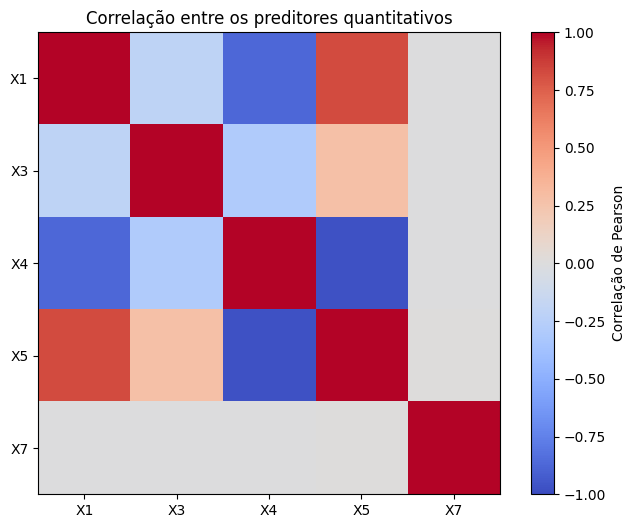

In [313]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlação de Pearson")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlação entre os preditores quantitativos")

plt.show()

### 3.1 Variance Inflation Factor (VIF)

O Variance Inflation Factor (VIF) é utilizado para avaliar o grau de multicolinearidade associado a cada variável explicativa. Para um determinado preditor $X_j$, define-se

$$
VIF_j = \frac{1}{1-R_j^2},
$$

em que $R_j^2$ é o coeficiente de determinação obtido ao ajustar $X_j$ como variável resposta em função dos demais preditores.

Assim, o VIF mede quanto a variância da estimativa do coeficiente associado a $X_j$ é inflacionada pela relação linear entre esse preditor e os demais.

Quando $R_j^2$ é próximo de 1, grande parte da variação de $X_j$ pode ser explicada pelos outros preditores, fazendo com que o VIF assuma valores elevados.

É importante destacar que o VIF é utilizado para investigar multicolinearidade, e não para detectar exclusivamente relações determinísticas como a identificada anteriormente entre X2, X3 e X4.


In [314]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [315]:
model_predictors = [
    "X1",
    "X3",
    "X4",
    "X5",
    "X7",
    "X6_3",
    "X6_4",
    "X6_5",
    "X8_1",
    "X8_2",
    "X8_3",
    "X8_4",
    "X8_5"
]

X_vif = df_model[model_predictors]

X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "Variável": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_table

,Variável,VIF
0,const,1.000000
1,X1,105.524054
2,X3,27.662740
3,X4,211.938336
4,X5,31.205474
5,X7,1.260417
6,X6_3,1.500000
7,X6_4,1.500000
8,X6_5,1.500000
9,X8_1,3.927083


### 3.2 Interpretação dos resultados

O diagnóstico de multicolinearidade revelou diferenças importantes entre os preditores. X1, X3, X4 e X5 apresentaram valores de VIF elevados, com destaque para X4, cujo VIF foi aproximadamente 211,94. X1, X3 e X5 também apresentaram valores elevados, de aproximadamente 105,52, 27,66 e 31,21, respectivamente.

Esses resultados indicam forte redundância linear entre as variáveis geométricas. Em particular, para X4, o valor do VIF implica um $R_j^2$ de aproximadamente 0,995, indicando que cerca de 99,5% da variabilidade de X4 pode ser explicada linearmente pelos demais preditores considerados no diagnóstico.

Os resultados são consistentes com as associações observadas anteriormente entre as características geométricas dos edifícios. Entretanto, diferentemente da relação exata $X_2=X_3+2X_4$, a multicolinearidade observada entre X1, X3, X4 e X5 não representa dependência linear perfeita. Assim, os coeficientes continuam sendo estimáveis, mas suas estimativas podem apresentar elevada variabilidade e menor precisão.

Por outro lado, X7 apresentou VIF próximo de 1, indicando baixa relação linear com os demais preditores. As variáveis indicadoras associadas a X6 também apresentaram VIF baixo, enquanto as dummies de X8 apresentaram valores próximos de 3,93, indicando uma associação moderada, mas substancialmente inferior à observada entre as variáveis geométricas.

Dessa forma, o principal problema de multicolinearidade remanescente concentra-se no conjunto X1, X3, X4 e X5. Essa característica deverá ser considerada na construção e comparação dos modelos, mas não será utilizada isoladamente como critério automático para exclusão de variáveis.


## 4. Construção e comparação dos modelos

Após a análise da estrutura de dependência entre os preditores e do diagnóstico preliminar de multicolinearidade, inicia-se a construção dos modelos de Regressão Linear Múltipla para as variáveis resposta Y1 (Heating Load) e Y2 (Cooling Load).

A estratégia adotada não consiste na definição antecipada de um único modelo final. Em vez disso, serão consideradas diferentes especificações do conjunto de variáveis explicativas, permitindo avaliar como a inclusão ou exclusão de determinados preditores afeta o ajuste, a precisão das estimativas e a complexidade do modelo.

A comparação será realizada considerando medidas de ajuste e parcimônia, como $R^2$, $R^2$ ajustado, AIC e BIC, além da análise da significância dos coeficientes, do teste F global e dos indicadores de multicolinearidade.

Particular atenção será dada às variáveis geométricas X2, X3 e X4. Como foi demonstrada uma dependência linear perfeita entre as três, não serão consideradas especificações que contenham simultaneamente X2, X3 e X4.

Além dos modelos obtidos por procedimentos de seleção de variáveis, serão analisadas especificações alternativas para a representação das características geométricas, permitindo avaliar o efeito da escolha dos preditores sobre os resultados inferenciais.


### 4.1 Espaço de modelos admissíveis

Considerando as oito variáveis explicativas originais, existem

$$
2^8-1=255
$$

subconjuntos não vazios de preditores.

Entretanto, as especificações que contêm simultaneamente X2, X3 e X4 não são admissíveis, devido à dependência linear perfeita

$$
X_2=X_3+2X_4.
$$

Como as demais cinco variáveis podem ser incluídas ou não independentemente, existem

$$
2^5=32
$$

especificações que apresentam essa dependência.

Consequentemente, o espaço de busca contém

$$
255-32=223
$$

modelos conceitualmente admissíveis.

As variáveis categóricas X6 e X8 são tratadas como unidades de seleção: quando uma delas é incluída, todas as suas variáveis indicadoras correspondentes são incorporadas conjuntamente à matriz de projeto.


### 4.2 Representação das variáveis nos modelos

Para a construção sistemática dos modelos, é necessário diferenciar as variáveis originais das colunas efetivamente utilizadas na matriz de projeto.

As variáveis quantitativas são representadas diretamente por suas respectivas colunas. Já X6 e X8, por serem categóricas, são representadas por conjuntos de variáveis indicadoras obtidos durante a preparação dos dados.

Dessa forma, cada variável original será tratada como uma unidade de seleção, enquanto sua representação interna poderá corresponder a uma ou várias colunas da matriz de projeto. Essa estrutura permite automatizar a construção dos modelos sem perder a interpretação das variáveis originais.


In [316]:
# Define as colunas da matriz de projeto correspondentes a cada variável original.
variable_columns = {
    "X1": ["X1"],
    "X2": ["X2"],
    "X3": ["X3"],
    "X4": ["X4"],
    "X5": ["X5"],
    "X6": ["X6_3", "X6_4", "X6_5"],
    "X7": ["X7"],
    "X8": ["X8_1", "X8_2", "X8_3", "X8_4", "X8_5"]
}

### 4.3 Construção automatizada dos modelos

Como diferentes especificações serão avaliadas ao longo da análise, a matriz de projeto será construída de forma automatizada a partir das variáveis originais selecionadas.

A função definida a seguir recebe a variável resposta e o conjunto de preditores conceituais, expande automaticamente as variáveis categóricas para suas respectivas dummies e adiciona o intercepto ao modelo.


In [317]:
# Cria uma função para construir e estimar um MRLM a partir das variáveis conceituais selecionadas.
def fit_mrlm(response, variables):
    columns = []

    for variable in variables:
        columns.extend(variable_columns[variable])

    X = df_model[columns]
    X = sm.add_constant(X)

    y = df_model[response]

    model = sm.OLS(y, X).fit()

    return model

### 4.4 Modelos de referência

Antes da avaliação sistemática das especificações admissíveis, serão construídos modelos de referência para investigar o efeito da representação das variáveis geométricas.

Como X2, X3 e X4 apresentam dependência linear perfeita, serão consideradas três representações alternativas para esse conjunto:

$$
(X_3,X_4), \qquad (X_2,X_3), \qquad (X_2,X_4).
$$

Em cada representação, as demais variáveis X1, X5, X6, X7 e X8 serão mantidas. Dessa forma, será possível avaliar se a escolha das variáveis geométricas altera significativamente o comportamento das estimativas e das medidas de ajuste.

Esses modelos não serão definidos como modelos finais. Eles servirão como referências para a comparação das diferentes especificações que serão avaliadas posteriormente.


In [318]:
# Estima o modelo de referência Y1 utilizando X3 e X4 como representação geométrica.
model_y1_x3_x4 = fit_mrlm(
    "Y1",
    ["X1", "X3", "X4", "X5", "X6", "X7", "X8"]
)

print(model_y1_x3_x4.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     706.0
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:01:53   Log-Likelihood:                -1874.5
No. Observations:                 768   AIC:                             3777.
Df Residuals:                     754   BIC:                             3842.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.1615     18.189      4.462      0.0

In [319]:
# Estima o modelo de referência Y1 utilizando X2 e X3 como representação geométrica.
model_y1_x2_x3 = fit_mrlm(
    "Y1",
    ["X1", "X2", "X3", "X5", "X6", "X7", "X8"]
)

print(model_y1_x2_x3.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     706.0
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:01:53   Log-Likelihood:                -1874.5
No. Observations:                 768   AIC:                             3777.
Df Residuals:                     754   BIC:                             3842.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.1615     18.189      4.462      0.0

In [320]:
# Estima o modelo de referência Y1 utilizando X2 e X4 como representação geométrica.
model_y1_x2_x4 = fit_mrlm(
    "Y1",
    ["X1", "X2", "X4", "X5", "X6", "X7", "X8"]
)

print(model_y1_x2_x4.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     706.0
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:01:53   Log-Likelihood:                -1874.5
No. Observations:                 768   AIC:                             3777.
Df Residuals:                     754   BIC:                             3842.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.1615     18.189      4.462      0.0

#### 4.4.1 Equivalência das representações geométricas

Os três modelos de referência apresentaram exatamente os mesmos valores para $R^2$, $R^2$ ajustado, estatística F, AIC e BIC, além de produzirem os mesmos valores ajustados e resíduos.

Esse resultado decorre diretamente da dependência linear

$$
X_2=X_3+2X_4.
$$

Consequentemente, qualquer duas das três variáveis $X_2$, $X_3$ e $X_4$ geram o mesmo espaço de preditores. A escolha de uma representação ou outra modifica a parametrização e, consequentemente, os valores individuais dos coeficientes, mas não altera os valores ajustados pelo modelo.

Portanto, as especificações envolvendo $(X_2,X_3)$, $(X_2,X_4)$ e $(X_3,X_4)$ não devem ser interpretadas como modelos distintos em termos de capacidade de ajuste. Elas representam a mesma componente geométrica do modelo por meio de diferentes parametrizações.

Para as etapas de seleção e comparação, será adotada uma representação canônica, utilizando X3 e X4. As representações alternativas envolvendo X2 serão retomadas posteriormente como uma análise da interpretação dos coeficientes e da representação das características geométricas.


In [321]:
# Verifica se os três modelos geométricos produzem os mesmos valores ajustados.
pred_x3_x4 = model_y1_x3_x4.fittedvalues
pred_x2_x3 = model_y1_x2_x3.fittedvalues
pred_x2_x4 = model_y1_x2_x4.fittedvalues

print("Diferença máxima entre X3+X4 e X2+X3:",
      np.max(np.abs(pred_x3_x4 - pred_x2_x3)))

print("Diferença máxima entre X3+X4 e X2+X4:",
      np.max(np.abs(pred_x3_x4 - pred_x2_x4)))

Diferença máxima entre X3+X4 e X2+X3: 1.764988155628089e-11
Diferença máxima entre X3+X4 e X2+X4: 2.0762058738910127e-11


### 4.5 Modelo completo de referência para Y1

A primeira especificação a ser analisada corresponde ao modelo completo dentro da parametrização geométrica adotada. O modelo inclui todas as variáveis explicativas consideradas admissíveis, mantendo X3 e X4 como representação das características geométricas relacionadas a X2.

Assim, o modelo pode ser escrito como

$$
Y_1 =
\beta_0+
\beta_1X_1+
\beta_3X_3+
\beta_4X_4+
\beta_5X_5+
\beta_7X_7+
\boldsymbol{\gamma}^{T}X_6+
\boldsymbol{\delta}^{T}X_8+
\varepsilon,
$$

em que $X_6$ e $X_8$ representam, respectivamente, os conjuntos de variáveis indicadoras definidos na etapa de preparação dos dados.

Esse modelo será utilizado como ponto de partida para os procedimentos de redução e comparação das especificações.


In [322]:
# Estima o modelo completo de referência para Y1 com todas as variáveis admissíveis.
model_y1_full = fit_mrlm(
    "Y1",
    ["X1", "X3", "X4", "X5", "X6", "X7", "X8"]
)

print(model_y1_full.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     706.0
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:01:53   Log-Likelihood:                -1874.5
No. Observations:                 768   AIC:                             3777.
Df Residuals:                     754   BIC:                             3842.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.1615     18.189      4.462      0.0

In [323]:
# Extrai as principais medidas de ajuste e complexidade de um modelo estimado.
def model_metrics(model):
    return {
        "R²": model.rsquared,
        "R² ajustado": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic,
        "F": model.fvalue,
        "p-valor F": model.f_pvalue,
        "Parâmetros": len(model.params),
        "GL resíduos": model.df_resid,
        "SSE": np.sum(model.resid ** 2),
        "MSE": np.mean(model.resid ** 2),
        "RMSE": np.sqrt(np.mean(model.resid ** 2))
    }

### 4.6 Modelo reduzido sem X6

O modelo completo apresentou ausência de significância individual para todas as variáveis indicadoras associadas a X6. Entretanto, como essas variáveis representam conjuntamente uma única característica categórica, sua remoção deve ser avaliada de forma conjunta.

Será construído, portanto, um modelo reduzido que exclui o bloco X6 e mantém os demais preditores. A comparação entre os modelos será posteriormente realizada considerando tanto as medidas de ajuste quanto um teste F parcial para avaliar a contribuição conjunta de X6.


In [324]:
# Estima o segundo modelo de Y1 removendo conjuntamente o bloco de variáveis indicadoras de X6.
model_y1_no_x6 = fit_mrlm(
    "Y1",
    ["X1", "X3", "X4", "X5", "X7", "X8"]
)

print(model_y1_no_x6.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     921.2
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:01:53   Log-Likelihood:                -1874.6
No. Observations:                 768   AIC:                             3771.
Df Residuals:                     757   BIC:                             3822.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.1558     18.155      4.470      0.0

In [325]:
# Compara as principais medidas de ajuste entre o modelo completo e o modelo sem X6.
models_y1 = pd.DataFrame({
    "Modelo completo": model_metrics(model_y1_full),
    "Sem X6": model_metrics(model_y1_no_x6)
}).T

display(models_y1)

,R²,R² ajustado,AIC,BIC,F,p-valor F,Parâmetros,GL resíduos,SSE,MSE,RMSE
Modelo completo,0.924083,0.922774,3777.062216,3842.075273,705.990853,0.0,14.0,754.0,5928.367117,7.719228,2.778350
Sem X6,0.924062,0.923058,3771.278186,3822.359873,921.159419,0.0,11.0,757.0,5930.034468,7.721399,2.778741


In [326]:
# Testa conjuntamente se a retirada do bloco X6 provoca perda estatisticamente significativa de ajuste.
f_test_x6 = model_y1_full.compare_f_test(model_y1_no_x6)

print("Estatística F:", f_test_x6[0])
print("p-valor:", f_test_x6[1])
print("Diferença nos graus de liberdade:", f_test_x6[2])

Estatística F: 0.07068739460368449
p-valor: 0.9756006593020056
Diferença nos graus de liberdade: 3.0


#### 4.6.1 Interpretação da retirada de X6

A comparação entre o modelo completo e o modelo sem X6 mostrou que a remoção conjunta das três variáveis indicadoras associadas a X6 não provocou perda estatisticamente significativa de ajuste. O teste F parcial apresentou estatística de 0,0707 e p-valor de 0,9756, não havendo evidência para rejeitar a hipótese de que os coeficientes associados a X6 sejam simultaneamente iguais a zero.

A retirada de X6 também provocou uma redução praticamente desprezível no $R^2$, de 0,924083 para 0,924062. Em contrapartida, o $R^2$ ajustado aumentou de 0,922774 para 0,923058, enquanto AIC e BIC foram reduzidos.

Dessa forma, considerando o conjunto de preditores presente nessa especificação, a remoção de X6 resulta em um modelo mais parcimonioso sem perda relevante de capacidade explicativa. A interpretação deve ser feita de forma condicional: o resultado indica que X6 não apresenta contribuição estatisticamente significativa para Y1 na presença dos demais preditores incluídos no modelo, e não que a variável seja necessariamente irrelevante de forma isolada.


### 4.7 Avaliação das demais variáveis

Após a remoção de X6, passa-se a avaliar a contribuição das demais variáveis presentes no modelo reduzido. Para cada preditor, será considerada uma especificação obtida por sua retirada individual, mantendo-se os demais componentes constantes.

A comparação será realizada por meio das medidas de ajuste e, para modelos aninhados, pelo teste F parcial. Essa análise permite identificar quais variáveis apresentam menor contribuição para o modelo atual e, portanto, quais constituem candidatos mais fortes à próxima etapa de redução.


In [327]:
# Define as variáveis ou blocos candidatos à próxima etapa de remoção.
current_variables = ["X1", "X3", "X4", "X5", "X7", "X8"]

removal_candidates = {
    "Sem X1": ["X3", "X4", "X5", "X7", "X8"],
    "Sem X3": ["X1", "X4", "X5", "X7", "X8"],
    "Sem X4": ["X1", "X3", "X5", "X7", "X8"],
    "Sem X5": ["X1", "X3", "X4", "X7", "X8"],
    "Sem X7": ["X1", "X3", "X4", "X5", "X8"],
    "Sem X8": ["X1", "X3", "X4", "X5", "X7"]
}

In [328]:
# Estima todos os modelos obtidos pela remoção individual de cada preditor ou bloco.
candidate_models = {}

for label, variables in removal_candidates.items():
    candidate_models[label] = fit_mrlm("Y1", variables)

candidate_metrics = []

for label, model in candidate_models.items():
    metrics = model_metrics(model)
    metrics["Modelo"] = label
    candidate_metrics.append(metrics)

candidate_metrics = pd.DataFrame(candidate_metrics)

candidate_metrics = candidate_metrics[
    [
        "Modelo",
        "R²",
        "R² ajustado",
        "AIC",
        "BIC",
        "F",
        "p-valor F",
        "Parâmetros",
        "MSE",
        "RMSE"
    ]
]

display(candidate_metrics)

,Modelo,R²,R² ajustado,AIC,BIC,F,p-valor F,Parâmetros,MSE,RMSE
0,Sem X1,0.919692,0.918739,3812.244011,3858.681908,964.518403,0.0,10,8.165685,2.857566
1,Sem X3,0.923588,0.922681,3774.054170,3820.492068,1017.986830,0.0,10,7.769566,2.787394
2,Sem X4,0.921180,0.920244,3797.879301,3844.317198,984.318696,0.0,10,8.014373,2.830967
3,Sem X5,0.907278,0.906177,3922.631139,3969.069037,824.111711,0.0,10,9.427905,3.070489
4,Sem X7,0.884802,0.883434,4089.324341,4135.762238,646.887567,0.0,10,11.713269,3.422465
5,Sem X8,0.915259,0.914703,3845.510375,3873.373114,1646.018431,0.0,6,8.616448,2.935379


In [329]:
# Compara cada modelo reduzido com o modelo atual por meio do teste F parcial.
partial_f_results = []

for label, model in candidate_models.items():
    f_stat, p_value, df_diff = model_y1_no_x6.compare_f_test(model)

    partial_f_results.append({
        "Modelo": label,
        "F parcial": f_stat,
        "p-valor parcial": p_value,
        "GL removidos": int(df_diff)
    })

partial_f_results = pd.DataFrame(partial_f_results)

display(partial_f_results)

,Modelo,F parcial,p-valor parcial,GL removidos
0,Sem X1,43.557483,7.739319e-11,1
1,Sem X3,4.722246,3.008425e-02,1
2,Sem X4,28.722981,1.109468e-07,1
3,Sem X5,167.304514,1.017737e-34,1
4,Sem X7,391.359887,1.560134e-70,1
5,Sem X8,17.549976,1.804263e-16,5


#### 4.7.1 Identificação da próxima candidata à remoção

A avaliação das possíveis remoções mostrou que a retirada de qualquer uma das variáveis, com exceção de X3, produz perda mais evidente nas medidas de ajuste e no teste F parcial.

Entre os preditores avaliados, X3 apresentou a menor contribuição marginal segundo o teste F parcial, com p-valor de 0,0301. Embora esse resultado ainda indique significância estatística ao nível de 5%, X3 constitui a principal candidata à redução quando comparada às demais variáveis.

A comparação pelos critérios de informação apresentou resultados distintos. O AIC favoreceu a permanência de X3, enquanto o BIC apresentou valor ligeiramente menor após sua retirada. Essa diferença evidencia que os critérios de seleção podem conduzir a escolhas distintas, em função das diferentes penalizações atribuídas à complexidade do modelo.

Assim, X3 será avaliada como uma especificação alternativa, mas sua retirada não será considerada automaticamente justificada apenas pelo resultado de um único critério.


In [330]:
# Calcula o VIF dos preditores do modelo candidato sem X3.
X_no_x3 = df_model[
    [
        "X1",
        "X4",
        "X5",
        "X7",
        "X8_1",
        "X8_2",
        "X8_3",
        "X8_4",
        "X8_5"
    ]
]

X_no_x3 = sm.add_constant(X_no_x3)

vif_no_x3 = pd.DataFrame({
    "Variável": X_no_x3.columns,
    "VIF": [
        variance_inflation_factor(X_no_x3.values, i)
        for i in range(X_no_x3.shape[1])
    ]
})

display(vif_no_x3)

,Variável,VIF
0,const,1.000000
1,X1,4.171997
2,X4,24.225183
3,X5,18.862946
4,X7,1.260417
5,X8_1,3.927083
6,X8_2,3.927083
7,X8_3,3.927083
8,X8_4,3.927083
9,X8_5,3.927083


In [331]:
# Compara as estimativas e erros-padrão das variáveis comuns aos dois modelos.
coef_comparison = pd.DataFrame({
    "Coef. modelo atual": model_y1_no_x6.params,
    "EP modelo atual": model_y1_no_x6.bse,
    "Coef. sem X3": model_y1_no_x3.params,
    "EP sem X3": model_y1_no_x3.bse
})

display(coef_comparison)

,Coef. modelo atual,EP modelo atual,Coef. sem X3,EP sem X3
X1,-64.773432,9.814440,-43.871790,1.956255
X3,-0.026476,0.012184,NaN,NaN
X4,-0.174579,0.032574,-0.107960,0.011040
X5,4.169954,0.322387,4.610548,0.251264
X7,16.848333,0.851665,16.848333,0.853754
X8_1,4.527653,0.512770,4.527653,0.514028
X8_2,4.435986,0.512770,4.435986,0.514028
X8_3,4.183000,0.512770,4.183000,0.514028
X8_4,4.388208,0.512770,4.388208,0.514028
X8_5,4.182444,0.512770,4.182444,0.514028


#### 4.7.2 Efeito das remoções de X6 e X3 sobre a multicolinearidade

Como o diagnóstico de multicolinearidade é dependente do conjunto de preditores presentes no modelo, os valores de VIF devem ser acompanhados a cada etapa de redução. Assim, a comparação deve considerar inicialmente o modelo completo, posteriormente o modelo após a retirada de X6 e, por fim, a especificação obtida após a retirada de X3.

Essa análise permite identificar se a redução observada na multicolinearidade está associada à retirada de uma variável específica ou se resulta apenas de alterações no conjunto de preditores.

Após a retirada de X3, observou-se uma redução expressiva dos VIFs das demais variáveis geométricas. O VIF de X1, que era de aproximadamente 105,52 no modelo completo, passou para um valor muito inferior após as reduções. Da mesma forma, os VIFs de X4 e X5 também apresentaram quedas importantes.

A comparação entre as diferentes etapas de redução será utilizada para avaliar a influência das variáveis sobre a estabilidade das estimativas, sem atribuir a uma única remoção uma alteração que possa ter ocorrido ao longo de mais de uma etapa.


In [332]:
# Calcula os VIFs do modelo imediatamente após a retirada de X6.
X_after_x6 = df_model[
    [
        "X1",
        "X3",
        "X4",
        "X5",
        "X7",
        "X8_1",
        "X8_2",
        "X8_3",
        "X8_4",
        "X8_5"
    ]
]

X_after_x6 = sm.add_constant(X_after_x6)

vif_after_x6 = pd.DataFrame({
    "Variável": X_after_x6.columns,
    "VIF": [
        variance_inflation_factor(X_after_x6.values, i)
        for i in range(X_after_x6.shape[1])
    ]
})

display(vif_after_x6)

,Variável,VIF
0,const,1.000000
1,X1,105.524054
2,X3,27.662740
3,X4,211.938336
4,X5,31.205474
5,X7,1.260417
6,X8_1,3.927083
7,X8_2,3.927083
8,X8_3,3.927083
9,X8_4,3.927083


In [333]:
# Compara os VIFs das principais variáveis geométricas nas três etapas de redução.
vif_comparison = pd.DataFrame({
    "Modelo completo": vif_table.set_index("Variável")["VIF"],
    "Sem X6": vif_after_x6.set_index("Variável")["VIF"],
    "Sem X6 e X3": vif_no_x3.set_index("Variável")["VIF"]
})

display(
    vif_comparison.loc[
        ["X1", "X3", "X4", "X5"]
    ]
)

,Modelo completo,Sem X6,Sem X6 e X3
Variável,,,
X1,105.524054,105.524054,4.171997
X3,27.662740,27.662740,NaN
X4,211.938336,211.938336,24.225183
X5,31.205474,31.205474,18.862946


#### 4.7.3 Justificativa para a avaliação da retirada de X3

A avaliação da retirada de X3 apresentou um resultado menos conclusivo do que o observado para X6. Pelo teste F parcial, a remoção de X3 apresentou p-valor de aproximadamente 0,0301, inferior ao nível de significância de 5%. Portanto, sob esse critério, existe evidência estatística de que X3 contribui para o modelo na presença dos demais preditores, favorecendo sua permanência.

O AIC também favorece a manutenção de X3, uma vez que seu valor aumenta quando X3 é removida. Da mesma forma, o $R^2$ ajustado apresenta uma pequena redução após a retirada da variável. Assim, considerando exclusivamente esses critérios de ajuste e inferência, a remoção de X3 não seria recomendada.

Entretanto, a análise da multicolinearidade apresenta uma evidência relevante em sentido contrário. A retirada de X3 provoca uma redução muito expressiva dos VIFs das demais variáveis geométricas, especialmente de X1, X4 e X5. Essa redução também é acompanhada por uma diminuição considerável dos erros-padrão de seus coeficientes, indicando maior precisão nas estimativas individuais após a retirada de X3.

Esse resultado é particularmente importante porque a multicolinearidade elevada constitui uma característica marcante da estrutura dos preditores deste conjunto de dados. Embora sua presença não impeça a estimação do modelo, ela pode dificultar a identificação e a interpretação dos efeitos individuais das variáveis explicativas.

Além disso, o BIC apresenta valor inferior para o modelo sem X3, indicando preferência por uma especificação mais simples nesse caso. Assim, existem evidências em sentidos diferentes: o teste F parcial, o AIC e o $R^2$ ajustado favorecem a permanência de X3, enquanto o BIC e, principalmente, a forte redução da multicolinearidade favorecem sua retirada.

Dessa forma, a remoção de X3 não será tratada como uma decisão automática baseada em um único critério. Ela será mantida como uma especificação candidata, cuja adequação será avaliada em conjunto com outras alternativas, considerando simultaneamente qualidade de ajuste, parcimônia, significância estatística, estabilidade das estimativas e multicolinearidade.


### 4.8 Avaliação da retirada de X4

A análise anterior mostrou que a retirada de X3 produz uma redução expressiva da multicolinearidade, embora alguns critérios de ajuste e inferência favoreçam sua permanência. Para verificar se essa característica é específica de X3, será avaliada uma especificação alternativa na qual X4 é removida do mesmo modelo de referência utilizado nessa comparação.

A retirada de X4 será analisada sob os mesmos aspectos considerados para X3: alteração das medidas de ajuste, teste F parcial, comportamento dos critérios de informação, mudança dos erros-padrão e, principalmente, efeito sobre a multicolinearidade das variáveis geométricas remanescentes.

A comparação permitirá avaliar qual das duas variáveis produz uma redução mais favorável da multicolinearidade e qual apresenta o melhor equilíbrio entre estabilidade das estimativas e qualidade do ajuste.


In [334]:
# Estima o modelo candidato obtido pela retirada de X4 após a remoção de X6.
model_y1_no_x4 = fit_mrlm(
    "Y1",
    ["X1", "X3", "X5", "X7", "X8"]
)

In [335]:
# Compara as principais medidas de ajuste entre o modelo após a retirada de X6 e o modelo sem X4.
comparison_x4 = pd.DataFrame({
    "Sem X6": model_metrics(model_y1_no_x6),
    "Sem X6 e X4": model_metrics(model_y1_no_x4)
}).T

display(
    comparison_x4[
        [
            "R²",
            "R² ajustado",
            "AIC",
            "BIC",
            "F",
            "p-valor F",
            "Parâmetros",
            "SSE",
            "MSE",
            "RMSE"
        ]
    ]
)

,R²,R² ajustado,AIC,BIC,F,p-valor F,Parâmetros,SSE,MSE,RMSE
Sem X6,0.924062,0.923058,3771.278186,3822.359873,921.159419,0.0,11.0,5930.034468,7.721399,2.778741
Sem X6 e X4,0.921180,0.920244,3797.879301,3844.317198,984.318696,0.0,10.0,6155.038781,8.014373,2.830967


In [336]:
# Testa se a retirada de X4 provoca perda estatisticamente significativa de ajuste.
f_test_x4 = model_y1_no_x6.compare_f_test(model_y1_no_x4)

print(f"Estatística F: {f_test_x4[0]:.6f}")
print(f"p-valor: {f_test_x4[1]:.6f}")
print(f"GL removidos: {int(f_test_x4[2])}")

Estatística F: 28.722981
p-valor: 0.000000
GL removidos: 1


In [337]:
# Calcula os VIFs do modelo candidato após a retirada de X4.
X_after_x4 = df_model[
    [
        "X1",
        "X3",
        "X5",
        "X7",
        "X8_1",
        "X8_2",
        "X8_3",
        "X8_4",
        "X8_5"
    ]
]

X_after_x4 = sm.add_constant(X_after_x4)

vif_after_x4 = pd.DataFrame({
    "Variável": X_after_x4.columns,
    "VIF": [
        variance_inflation_factor(X_after_x4.values, i)
        for i in range(X_after_x4.shape[1])
    ]
})

display(vif_after_x4)

,Variável,VIF
0,const,1.000000
1,X1,9.250283
2,X3,3.161934
3,X5,9.626103
4,X7,1.260417
5,X8_1,3.927083
6,X8_2,3.927083
7,X8_3,3.927083
8,X8_4,3.927083
9,X8_5,3.927083


In [338]:
# Compara os VIFs resultantes das duas alternativas de redução do bloco geométrico.
vif_removal_comparison = pd.DataFrame({
    "Modelo sem X6": vif_after_x6.set_index("Variável")["VIF"],
    "Sem X6 e X3": vif_no_x3.set_index("Variável")["VIF"],
    "Sem X6 e X4": vif_after_x4.set_index("Variável")["VIF"]
})

display(
    vif_removal_comparison.loc[
        ["X1", "X3", "X4", "X5"]
    ]
)

,Modelo sem X6,Sem X6 e X3,Sem X6 e X4
Variável,,,
X1,105.524054,4.171997,9.250283
X3,27.662740,NaN,3.161934
X4,211.938336,24.225183,NaN
X5,31.205474,18.862946,9.626103


In [339]:
# Mede a redução percentual dos VIFs de X1 e X5 nas duas alternativas de remoção.
vif_reduction = pd.DataFrame({
    "Variável": ["X1", "X5"],
    "Redução ao remover X3 (%)": [
        (1 - vif_no_x3.set_index("Variável").loc["X1", "VIF"]
         / vif_after_x6.set_index("Variável").loc["X1", "VIF"]) * 100,
        (1 - vif_no_x3.set_index("Variável").loc["X5", "VIF"]
         / vif_after_x6.set_index("Variável").loc["X5", "VIF"]) * 100
    ],
    "Redução ao remover X4 (%)": [
        (1 - vif_after_x4.set_index("Variável").loc["X1", "VIF"]
         / vif_after_x6.set_index("Variável").loc["X1", "VIF"]) * 100,
        (1 - vif_after_x4.set_index("Variável").loc["X5", "VIF"]
         / vif_after_x6.set_index("Variável").loc["X5", "VIF"]) * 100
    ]
})

display(vif_reduction)

,Variável,Redução ao remover X3 (%),Redução ao remover X4 (%)
0,X1,96.046402,91.233958
1,X5,39.552445,69.152520


In [340]:
# Compara os erros-padrão das variáveis presentes nos três modelos.
common_variables_x4 = [
    "const",
    "X1",
    "X5",
    "X7",
    "X8_1",
    "X8_2",
    "X8_3",
    "X8_4",
    "X8_5"
]

coef_precision_x4 = pd.DataFrame({
    "EP — Sem X6": model_y1_no_x6.bse,
    "EP — Sem X6 e X3": model_y1_no_x3.bse,
    "EP — Sem X6 e X4": model_y1_no_x4.bse
}).reindex(common_variables_x4)

display(coef_precision_x4)

,EP — Sem X6,EP — Sem X6 e X3,EP — Sem X6 e X4
const,18.154914,4.008376,2.589482
X1,9.814440,1.956255,2.958472
X5,0.322387,0.251264,0.182300
X7,0.851665,0.853754,0.867099
X8_1,0.512770,0.514028,0.522063
X8_2,0.512770,0.514028,0.522063
X8_3,0.512770,0.514028,0.522063
X8_4,0.512770,0.514028,0.522063
X8_5,0.512770,0.514028,0.522063


#### 4.8.1 Comparação entre as alternativas de redução

A comparação entre as remoções de X3 e X4 evidencia que não existe um único critério capaz de determinar isoladamente a melhor especificação.

A retirada de X3 produz uma redução mais acentuada do VIF de X1 e mantém perdas muito pequenas nas medidas de ajuste, além de apresentar redução no BIC. Entretanto, sua remoção ainda é desfavorecida pelo teste F parcial e pelo AIC.

A retirada de X4, por sua vez, produz uma redução mais equilibrada da multicolinearidade entre as variáveis geométricas remanescentes, fazendo com que os maiores VIFs do conjunto analisado fiquem consideravelmente menores. Entretanto, essa redução ocorre acompanhada de perdas mais expressivas nas medidas de ajuste e de uma contribuição marginal estatisticamente significativa de X4, evidenciada pelo teste F parcial.

Dessa forma, os resultados não justificam a eliminação imediata de uma das duas variáveis. As duas especificações serão mantidas como alternativas para as etapas seguintes de seleção, permitindo verificar como novas inclusões ou exclusões de preditores alteram simultaneamente o ajuste e a estrutura de multicolinearidade.

Essa abordagem é particularmente importante porque a multicolinearidade depende do conjunto de variáveis incluído no modelo. Portanto, a avaliação de uma variável isoladamente em uma única etapa de redução pode não representar seu comportamento em especificações subsequentes.

### 4.9 Critérios de seleção dos modelos

A seleção dos modelos será realizada de forma sistemática, evitando que a escolha de uma especificação dependa exclusivamente de um único critério estatístico.

Serão consideradas conjuntamente medidas de ajuste, complexidade, inferência e multicolinearidade. Entre as principais medidas utilizadas estarão o $R^2$, o $R^2$ ajustado, o AIC, o BIC, o RMSE e os indicadores de multicolinearidade obtidos por meio do VIF.

O $R^2$ será utilizado como medida descritiva da proporção da variabilidade da variável resposta explicada pelo modelo. Como essa medida não penaliza a inclusão de novos preditores, sua utilização na seleção será complementar.

O $R^2$ ajustado será utilizado para considerar simultaneamente a qualidade do ajuste e a complexidade do modelo. Valores maiores indicam melhor equilíbrio entre esses dois aspectos.

O AIC e o BIC serão utilizados como critérios de informação para comparar especificações com diferentes níveis de complexidade. Em ambos os casos, valores menores indicam maior preferência pelo modelo segundo o respectivo critério, com o BIC impondo uma penalização mais forte à complexidade.

A precisão das estimativas também será considerada por meio do RMSE e, nas etapas posteriores, pela comparação dos erros-padrão e da estabilidade dos coeficientes entre especificações alternativas.

A multicolinearidade será avaliada por meio dos VIFs das variáveis presentes em cada modelo. O VIF não será utilizado como regra automática de exclusão, mas como elemento de avaliação da estabilidade e da interpretabilidade das estimativas.

Para modelos aninhados, o teste F parcial será utilizado para avaliar se a remoção de uma variável ou bloco de variáveis provoca perda estatisticamente significativa de ajuste.

Dessa forma, a escolha dos modelos candidatos será baseada em uma análise multicritério. Nenhuma especificação será considerada superior apenas por apresentar o menor AIC, o menor BIC, o maior $R^2$ ajustado ou o menor VIF isoladamente.


In [341]:
# Gera os modelos conceitualmente distintos para a busca exaustiva.
from itertools import combinations

other_variables = ["X1", "X5", "X6", "X7", "X8"]

geometry_options = [
    ("Nenhuma", []),
    ("X2", ["X2"]),
    ("X3", ["X3"]),
    ("X4", ["X4"]),
    ("X3 + X4", ["X3", "X4"])
]

model_candidates = []

for r in range(len(other_variables) + 1):
    for others in combinations(other_variables, r):
        for geometry_label, geometry_variables in geometry_options:
            variables = list(others) + geometry_variables

            if not variables:
                continue

            ordered_variables = [
                variable
                for variable in ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]
                if variable in variables
            ]

            model_candidates.append({
                "Geometria": geometry_label,
                "Variaveis": ordered_variables
            })

print("Número de modelos conceitualmente distintos:", len(model_candidates))

Número de modelos conceitualmente distintos: 159


In [342]:
# Estima todos os modelos candidatos e calcula métricas de ajuste, complexidade e multicolinearidade.
from statsmodels.stats.outliers_influence import variance_inflation_factor

selection_results = []

for model_id, candidate in enumerate(model_candidates, start=1):

    variables = candidate["Variaveis"]
    model = fit_mrlm("Y1", variables)

    columns = []
    for variable in variables:
        columns.extend(variable_columns[variable])

    X_vif = sm.add_constant(df_model[columns], has_constant="add")

    vif_values = [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]

    vif_predictors = vif_values[1:]

    metrics = model_metrics(model)

    selection_results.append({
        "Modelo": model_id,
        "Preditores": " + ".join(variables),
        "Geometria": candidate["Geometria"],
        "R²": metrics["R²"],
        "R² ajustado": metrics["R² ajustado"],
        "AIC": metrics["AIC"],
        "BIC": metrics["BIC"],
        "RMSE": metrics["RMSE"],
        "Max VIF": max(vif_predictors),
        "VIF ≥ 5": sum(v >= 5 for v in vif_predictors),
        "VIF ≥ 10": sum(v >= 10 for v in vif_predictors),
        "Parâmetros": metrics["Parâmetros"]
    })

selection_results = pd.DataFrame(selection_results)

display(selection_results.head())

,Modelo,Preditores,Geometria,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
0,1,X2,X2,0.433122,0.432382,5297.127712,5306.415292,7.592099,1.000000,0,0,2
1,2,X3,X3,0.207636,0.206602,5554.312453,5563.600033,8.975926,1.000000,0,0,2
2,3,X4,X4,0.742748,0.742412,4690.341142,4699.628721,5.114424,1.000000,0,0,2
3,4,X3 + X4,X3 + X4,0.788138,0.787584,4543.254534,4557.185903,4.641340,1.093433,0,0,3
4,5,X1,Nenhuma,0.387222,0.386422,5356.922430,5366.210009,7.893479,1.000000,0,0,2


In [344]:
# Mostra os dez melhores modelos segundo AIC, BIC, R² ajustado e RMSE.
top_aic = selection_results.nsmallest(10, "AIC")
top_bic = selection_results.nsmallest(10, "BIC")
top_adj_r2 = selection_results.nlargest(10, "R² ajustado")
top_rmse = selection_results.nsmallest(10, "RMSE")

print("10 melhores por AIC")
display(top_aic)

print("10 melhores por BIC")
display(top_bic)

print("10 melhores por R² ajustado")
display(top_adj_r2)

print("10 melhores por RMSE")
display(top_rmse)

10 melhores por AIC


,Modelo,Preditores,Geometria,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
143,144,X1 + X3 + X4 + X5 + X7 + X8,X3 + X4,0.924062,0.923058,3771.278186,3822.359873,2.778741,211.938336,4,4,11
142,143,X1 + X4 + X5 + X7 + X8,X4,0.923588,0.922681,3774.054170,3820.492068,2.787394,24.225183,2,2,10
158,159,X1 + X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.924083,0.922774,3777.062216,3842.075273,2.778350,211.938336,4,4,14
157,158,X1 + X4 + X5 + X6 + X7 + X8,X4,0.923609,0.922395,3779.839540,3840.208807,2.787005,24.225183,2,2,13
141,142,X1 + X3 + X5 + X7 + X8,X3,0.921180,0.920244,3797.879301,3844.317198,2.830967,9.626103,2,0,10
156,157,X1 + X3 + X5 + X6 + X7 + X8,X3,0.921202,0.919949,3803.671227,3864.040494,2.830583,9.626103,2,0,13
123,124,X3 + X4 + X5 + X7 + X8,X3 + X4,0.919692,0.918739,3812.244011,3858.681908,2.857566,18.578604,2,2,10
153,154,X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.919713,0.918437,3818.039794,3878.409060,2.857186,18.578604,2,2,13
121,122,X3 + X5 + X7 + X8,X3,0.918671,0.917814,3819.945616,3861.739724,2.875672,3.927083,0,0,9
151,152,X3 + X5 + X6 + X7 + X8,X3,0.918692,0.917509,3825.743963,3881.469440,2.875295,3.927083,0,0,12


10 melhores por BIC


,Modelo,Preditores,Geometria,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
142,143,X1 + X4 + X5 + X7 + X8,X4,0.923588,0.922681,3774.054170,3820.492068,2.787394,24.225183,2,2,10
143,144,X1 + X3 + X4 + X5 + X7 + X8,X3 + X4,0.924062,0.923058,3771.278186,3822.359873,2.778741,211.938336,4,4,11
157,158,X1 + X4 + X5 + X6 + X7 + X8,X4,0.923609,0.922395,3779.839540,3840.208807,2.787005,24.225183,2,2,13
158,159,X1 + X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.924083,0.922774,3777.062216,3842.075273,2.778350,211.938336,4,4,14
141,142,X1 + X3 + X5 + X7 + X8,X3,0.921180,0.920244,3797.879301,3844.317198,2.830967,9.626103,2,0,10
123,124,X3 + X4 + X5 + X7 + X8,X3 + X4,0.919692,0.918739,3812.244011,3858.681908,2.857566,18.578604,2,2,10
121,122,X3 + X5 + X7 + X8,X3,0.918671,0.917814,3819.945616,3861.739724,2.875672,3.927083,0,0,9
156,157,X1 + X3 + X5 + X6 + X7 + X8,X3,0.921202,0.919949,3803.671227,3864.040494,2.830583,9.626103,2,0,13
87,88,X1 + X4 + X5 + X7,X4,0.914785,0.914338,3847.791626,3871.010575,2.943572,24.225183,2,2,5
88,89,X1 + X3 + X4 + X5 + X7,X3 + X4,0.915259,0.914703,3845.510375,3873.373114,2.935379,211.938336,4,4,6


10 melhores por R² ajustado


,Modelo,Preditores,Geometria,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
143,144,X1 + X3 + X4 + X5 + X7 + X8,X3 + X4,0.924062,0.923058,3771.278186,3822.359873,2.778741,211.938336,4,4,11
158,159,X1 + X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.924083,0.922774,3777.062216,3842.075273,2.778350,211.938336,4,4,14
142,143,X1 + X4 + X5 + X7 + X8,X4,0.923588,0.922681,3774.054170,3820.492068,2.787394,24.225183,2,2,10
157,158,X1 + X4 + X5 + X6 + X7 + X8,X4,0.923609,0.922395,3779.839540,3840.208807,2.787005,24.225183,2,2,13
141,142,X1 + X3 + X5 + X7 + X8,X3,0.921180,0.920244,3797.879301,3844.317198,2.830967,9.626103,2,0,10
156,157,X1 + X3 + X5 + X6 + X7 + X8,X3,0.921202,0.919949,3803.671227,3864.040494,2.830583,9.626103,2,0,13
123,124,X3 + X4 + X5 + X7 + X8,X3 + X4,0.919692,0.918739,3812.244011,3858.681908,2.857566,18.578604,2,2,10
153,154,X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.919713,0.918437,3818.039794,3878.409060,2.857186,18.578604,2,2,13
121,122,X3 + X5 + X7 + X8,X3,0.918671,0.917814,3819.945616,3861.739724,2.875672,3.927083,0,0,9
151,152,X3 + X5 + X6 + X7 + X8,X3,0.918692,0.917509,3825.743963,3881.469440,2.875295,3.927083,0,0,12


10 melhores por RMSE


,Modelo,Preditores,Geometria,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
158,159,X1 + X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.924083,0.922774,3777.062216,3842.075273,2.778350,211.938336,4,4,14
143,144,X1 + X3 + X4 + X5 + X7 + X8,X3 + X4,0.924062,0.923058,3771.278186,3822.359873,2.778741,211.938336,4,4,11
157,158,X1 + X4 + X5 + X6 + X7 + X8,X4,0.923609,0.922395,3779.839540,3840.208807,2.787005,24.225183,2,2,13
142,143,X1 + X4 + X5 + X7 + X8,X4,0.923588,0.922681,3774.054170,3820.492068,2.787394,24.225183,2,2,10
156,157,X1 + X3 + X5 + X6 + X7 + X8,X3,0.921202,0.919949,3803.671227,3864.040494,2.830583,9.626103,2,0,13
141,142,X1 + X3 + X5 + X7 + X8,X3,0.921180,0.920244,3797.879301,3844.317198,2.830967,9.626103,2,0,10
153,154,X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.919713,0.918437,3818.039794,3878.409060,2.857186,18.578604,2,2,13
123,124,X3 + X4 + X5 + X7 + X8,X3 + X4,0.919692,0.918739,3812.244011,3858.681908,2.857566,18.578604,2,2,10
151,152,X3 + X5 + X6 + X7 + X8,X3,0.918692,0.917509,3825.743963,3881.469440,2.875295,3.927083,0,0,12
121,122,X3 + X5 + X7 + X8,X3,0.918671,0.917814,3819.945616,3861.739724,2.875672,3.927083,0,0,9


#### 4.9.1 Síntese inicial dos critérios de seleção

A busca sistemática revelou que os diferentes critérios de seleção não conduzem necessariamente à mesma especificação. O modelo 144 apresentou o menor AIC e o maior $R^2$ ajustado entre os modelos avaliados, indicando excelente desempenho em termos de ajuste e equilíbrio entre capacidade explicativa e complexidade. Entretanto, esse modelo ainda apresenta forte multicolinearidade, com VIF máximo de aproximadamente 211,94.

O modelo 143 apresentou o menor BIC e manteve desempenho de ajuste muito próximo ao modelo 144. Ao mesmo tempo, a exclusão de X3 reduziu substancialmente o VIF máximo, de aproximadamente 211,94 para 24,23. Esse comportamento torna essa especificação especialmente relevante para a análise comparativa.

O modelo 142 apresentou uma redução adicional da multicolinearidade, com VIF máximo de aproximadamente 9,63, porém acompanhada por uma perda mais perceptível nas medidas de ajuste. Já o modelo 122 apresentou VIF máximo de aproximadamente 3,93, sem indicadores acima de 5, mas com redução adicional da capacidade explicativa.

O modelo 159 apresentou o menor RMSE, mas corresponde à especificação mais complexa e sua vantagem em relação ao modelo 144 foi muito pequena. Portanto, o RMSE calculado na amostra de ajuste não será utilizado isoladamente como critério de escolha.

Os resultados indicam que não existe, nesta etapa, um único modelo claramente superior segundo todos os critérios. Assim, os modelos serão submetidos a procedimentos adicionais de seleção e comparação, buscando identificar especificações que apresentem simultaneamente bom ajuste, parcimônia, menor multicolinearidade e maior estabilidade das estimativas.


In [345]:
# Calcula a posição de cada modelo nos critérios principais e cria um ranking auxiliar de consenso.
selection_ranked = selection_results.copy()

selection_ranked["Rank AIC"] = selection_ranked["AIC"].rank(method="min", ascending=True)
selection_ranked["Rank BIC"] = selection_ranked["BIC"].rank(method="min", ascending=True)
selection_ranked["Rank R² ajustado"] = selection_ranked["R² ajustado"].rank(method="min", ascending=False)
selection_ranked["Rank RMSE"] = selection_ranked["RMSE"].rank(method="min", ascending=True)

selection_ranked["Rank médio"] = selection_ranked[
    ["Rank AIC", "Rank BIC", "Rank R² ajustado", "Rank RMSE"]
].mean(axis=1)

consensus_models = selection_ranked.sort_values("Rank médio").head(15)

display(
    consensus_models[
        [
            "Modelo",
            "Preditores",
            "R² ajustado",
            "AIC",
            "BIC",
            "RMSE",
            "Max VIF",
            "Rank AIC",
            "Rank BIC",
            "Rank R² ajustado",
            "Rank RMSE",
            "Rank médio"
        ]
    ]
)

,Modelo,Preditores,R² ajustado,AIC,BIC,RMSE,Max VIF,Rank AIC,Rank BIC,Rank R² ajustado,Rank RMSE,Rank médio
143,144,X1 + X3 + X4 + X5 + X7 + X8,0.923058,3771.278186,3822.359873,2.778741,211.938336,1.0,2.0,1.0,2.0,1.50
142,143,X1 + X4 + X5 + X7 + X8,0.922681,3774.054170,3820.492068,2.787394,24.225183,2.0,1.0,3.0,4.0,2.50
158,159,X1 + X3 + X4 + X5 + X6 + X7 + X8,0.922774,3777.062216,3842.075273,2.778350,211.938336,3.0,4.0,2.0,1.0,2.50
157,158,X1 + X4 + X5 + X6 + X7 + X8,0.922395,3779.839540,3840.208807,2.787005,24.225183,4.0,3.0,4.0,3.0,3.50
141,142,X1 + X3 + X5 + X7 + X8,0.920244,3797.879301,3844.317198,2.830967,9.626103,5.0,5.0,5.0,6.0,5.25
156,157,X1 + X3 + X5 + X6 + X7 + X8,0.919949,3803.671227,3864.040494,2.830583,9.626103,6.0,8.0,6.0,5.0,6.25
123,124,X3 + X4 + X5 + X7 + X8,0.918739,3812.244011,3858.681908,2.857566,18.578604,7.0,6.0,7.0,8.0,7.00
153,154,X3 + X4 + X5 + X6 + X7 + X8,0.918437,3818.039794,3878.409060,2.857186,18.578604,8.0,11.0,8.0,7.0,8.50
121,122,X3 + X5 + X7 + X8,0.917814,3819.945616,3861.739724,2.875672,3.927083,9.0,7.0,9.0,10.0,8.75
151,152,X3 + X5 + X6 + X7 + X8,0.917509,3825.743963,3881.469440,2.875295,3.927083,10.0,12.0,10.0,9.0,10.25


### 4.10 Métodos de seleção de variáveis

Após a avaliação sistemática das especificações admissíveis, serão aplicados diferentes procedimentos de seleção de variáveis, com o objetivo de verificar se diferentes estratégias conduzem a modelos semelhantes.

Serão considerados os métodos backward, forward e stepwise, utilizando testes de significância parcial como mecanismo de entrada e remoção das variáveis. As variáveis categóricas X6 e X8 serão tratadas como blocos, de modo que seus conjuntos de variáveis indicadoras sejam incluídos ou removidos conjuntamente.

Também será considerada a estratégia de best subset selection, já representada pela avaliação exaustiva das especificações conceitualmente distintas. Nesse procedimento, todos os modelos admissíveis serão comparados segundo diferentes critérios de ajuste e parcimônia.

Os procedimentos de seleção terão caráter complementar, e não serão utilizados isoladamente para definir o modelo final. A convergência ou divergência entre os métodos será utilizada como evidência adicional na identificação dos modelos candidatos para a etapa posterior de diagnóstico e validação.


In [346]:
# Define funções auxiliares para estimar modelos e avaliar adições ou remoções de variáveis.
def fit_selection_model(response, variables):
    columns = []

    for variable in variables:
        columns.extend(variable_columns[variable])

    X = df_model[columns].copy()

    if len(columns) == 0:
        X = pd.DataFrame(index=df_model.index)

    X = sm.add_constant(X, has_constant="add")
    y = df_model[response]

    return sm.OLS(y, X).fit()


def is_admissible(variables):
    geometry_variables = {"X2", "X3", "X4"}

    return not geometry_variables.issubset(set(variables))


def partial_f_add(current_model, candidate_model):
    return candidate_model.compare_f_test(current_model)


def partial_f_remove(current_model, reduced_model):
    return current_model.compare_f_test(reduced_model)

In [349]:
# Executa o procedimento backward usando o teste F parcial para remoção de variáveis.
def backward_selection(response, initial_variables, alpha=0.05):
    current = initial_variables.copy()
    history = []

    while len(current) > 0:

        current_model = fit_selection_model(response, current)
        candidates = []

        for variable in current:

            reduced = [v for v in current if v != variable]

            if not is_admissible(reduced):
                continue

            reduced_model = fit_selection_model(response, reduced)
            f_stat, p_value, df_diff = partial_f_remove(
                current_model,
                reduced_model
            )

            candidates.append({
                "Variável removida": variable,
                "F parcial": f_stat,
                "p-valor": p_value,
                "GL removidos": df_diff,
                "Preditores resultantes": " + ".join(reduced)
            })

        candidates_df = pd.DataFrame(candidates)

        if candidates_df.empty:
            break

        best_removal = candidates_df.sort_values(
            "p-valor",
            ascending=False
        ).iloc[0]

        history.append({
            "Modelo atual": " + ".join(current),
            "Variável candidata": best_removal["Variável removida"],
            "F parcial": best_removal["F parcial"],
            "p-valor": best_removal["p-valor"]
        })

        if best_removal["p-valor"] <= alpha:
            break

        current.remove(best_removal["Variável removida"])

    final_model = fit_selection_model(response, current)

    return current, final_model, pd.DataFrame(history)

# Aplica o procedimento backward ao conjunto completo admissível de preditores para Y1.
backward_variables, model_y1_backward, backward_history = backward_selection(
    "Y1",
    ["X1", "X3", "X4", "X5", "X6", "X7", "X8"],
    alpha=0.05
)

print("Variáveis selecionadas:", backward_variables)
display(backward_history)
display(pd.DataFrame([model_metrics(model_y1_backward)]))

Variáveis selecionadas: ['X1', 'X3', 'X4', 'X5', 'X7', 'X8']


,Modelo atual,Variável candidata,F parcial,p-valor
0,X1 + X3 + X4 + X5 + X6 + X7 + X8,X6,0.070687,0.975601
1,X1 + X3 + X4 + X5 + X7 + X8,X3,4.722246,0.030084


,R²,R² ajustado,AIC,BIC,F,p-valor F,Parâmetros,GL resíduos,SSE,MSE,RMSE
0,0.924062,0.923058,3771.278186,3822.359873,921.159419,0.0,11,757.0,5930.034468,7.721399,2.778741


In [350]:
# Executa o procedimento forward usando o teste F parcial para entrada de variáveis.
def forward_selection(response, candidate_variables, alpha=0.05):
    current = []
    history = []

    while True:

        current_model = fit_selection_model(response, current)
        candidates = []

        for variable in candidate_variables:

            if variable in current:
                continue

            proposed = current + [variable]

            if not is_admissible(proposed):
                continue

            proposed_model = fit_selection_model(response, proposed)
            f_stat, p_value, df_diff = partial_f_add(
                current_model,
                proposed_model
            )

            candidates.append({
                "Variável adicionada": variable,
                "F parcial": f_stat,
                "p-valor": p_value,
                "GL adicionados": df_diff
            })

        candidates_df = pd.DataFrame(candidates)

        if candidates_df.empty:
            break

        best_addition = candidates_df.sort_values(
            "p-valor",
            ascending=True
        ).iloc[0]

        history.append({
            "Modelo atual": " + ".join(current) if current else "Intercepto",
            "Variável candidata": best_addition["Variável adicionada"],
            "F parcial": best_addition["F parcial"],
            "p-valor": best_addition["p-valor"]
        })

        if best_addition["p-valor"] >= alpha:
            break

        current.append(best_addition["Variável adicionada"])

    final_model = fit_selection_model(response, current)

    return current, final_model, pd.DataFrame(history)

# Aplica o procedimento forward a todos os preditores conceituais admissíveis para Y1.
forward_variables, model_y1_forward, forward_history = forward_selection(
    "Y1",
    ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"],
    alpha=0.05
)

print("Variáveis selecionadas:", forward_variables)
display(forward_history)
display(pd.DataFrame([model_metrics(model_y1_forward)]))

Variáveis selecionadas: ['X5', 'X7', 'X3', 'X8', 'X1', 'X2']


,Modelo atual,Variável candidata,F parcial,p-valor
0,Intercepto,X5,2900.590178,1.141704e-262
1,X5,X7,409.284085,3.162636e-73
2,X5 + X7,X3,389.642904,2.114645e-70
3,X5 + X7 + X3,X8,16.430079,2.041031e-15
4,X5 + X7 + X3 + X8,X1,24.129035,1.104199e-06
5,X5 + X7 + X3 + X8 + X1,X2,28.722981,1.109468e-07
6,X5 + X7 + X3 + X8 + X1 + X2,X6,0.070687,9.756007e-01


,R²,R² ajustado,AIC,BIC,F,p-valor F,Parâmetros,GL resíduos,SSE,MSE,RMSE
0,0.924062,0.923058,3771.278186,3822.359873,921.159419,0.0,11,757.0,5930.034468,7.721399,2.778741


In [351]:
# Executa o procedimento stepwise permitindo tanto a entrada quanto a remoção de variáveis.
def stepwise_selection(
    response,
    candidate_variables,
    alpha_enter=0.05,
    alpha_remove=0.10
):
    current = []
    history = []

    while True:

        changed = False

        # Etapa de entrada
        current_model = fit_selection_model(response, current)
        additions = []

        for variable in candidate_variables:

            if variable in current:
                continue

            proposed = current + [variable]

            if not is_admissible(proposed):
                continue

            proposed_model = fit_selection_model(response, proposed)
            f_stat, p_value, df_diff = partial_f_add(
                current_model,
                proposed_model
            )

            additions.append({
                "Variável": variable,
                "F parcial": f_stat,
                "p-valor": p_value
            })

        if additions:
            additions_df = pd.DataFrame(additions)
            best_addition = additions_df.sort_values(
                "p-valor"
            ).iloc[0]

            if best_addition["p-valor"] < alpha_enter:

                variable_added = best_addition["Variável"]
                current.append(variable_added)
                changed = True

                history.append({
                    "Etapa": "Entrada",
                    "Variável": variable_added,
                    "p-valor": best_addition["p-valor"],
                    "Modelo": " + ".join(current)
                })

        # Etapa de remoção
        current_model = fit_selection_model(response, current)
        removals = []

        for variable in current:

            reduced = [v for v in current if v != variable]

            if not is_admissible(reduced):
                continue

            reduced_model = fit_selection_model(response, reduced)
            f_stat, p_value, df_diff = partial_f_remove(
                current_model,
                reduced_model
            )

            removals.append({
                "Variável": variable,
                "F parcial": f_stat,
                "p-valor": p_value
            })

        if removals:
            removals_df = pd.DataFrame(removals)
            worst_variable = removals_df.sort_values(
                "p-valor",
                ascending=False
            ).iloc[0]

            if worst_variable["p-valor"] > alpha_remove:

                variable_removed = worst_variable["Variável"]
                current.remove(variable_removed)
                changed = True

                history.append({
                    "Etapa": "Remoção",
                    "Variável": variable_removed,
                    "p-valor": worst_variable["p-valor"],
                    "Modelo": " + ".join(current)
                })

        if not changed:
            break

    final_model = fit_selection_model(response, current)

    return current, final_model, pd.DataFrame(history)

# Aplica o procedimento stepwise ao conjunto completo de variáveis conceituais para Y1.
stepwise_variables, model_y1_stepwise, stepwise_history = stepwise_selection(
    "Y1",
    ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"],
    alpha_enter=0.05,
    alpha_remove=0.10
)

print("Variáveis selecionadas:", stepwise_variables)
display(stepwise_history)
display(pd.DataFrame([model_metrics(model_y1_stepwise)]))

Variáveis selecionadas: ['X5', 'X7', 'X3', 'X8', 'X1', 'X2']


,Etapa,Variável,p-valor,Modelo
0,Entrada,X5,1.141704e-262,X5
1,Entrada,X7,3.162636e-73,X5 + X7
2,Entrada,X3,2.114645e-70,X5 + X7 + X3
3,Entrada,X8,2.041031e-15,X5 + X7 + X3 + X8
4,Entrada,X1,1.104199e-06,X5 + X7 + X3 + X8 + X1
5,Entrada,X2,1.109468e-07,X5 + X7 + X3 + X8 + X1 + X2


,R²,R² ajustado,AIC,BIC,F,p-valor F,Parâmetros,GL resíduos,SSE,MSE,RMSE
0,0.924062,0.923058,3771.278186,3822.359873,921.159419,0.0,11,757.0,5930.034468,7.721399,2.778741


In [352]:
# Organiza a busca exaustiva para identificar os melhores subconjuntos por tamanho de modelo.
best_subset = selection_results.copy()

best_subset["N variáveis"] = best_subset["Preditores"].apply(
    lambda x: len(x.split(" + "))
)

best_by_size_aic = (
    best_subset
    .sort_values("AIC")
    .groupby("N variáveis", as_index=False)
    .first()
)

best_by_size_bic = (
    best_subset
    .sort_values("BIC")
    .groupby("N variáveis", as_index=False)
    .first()
)

best_by_size_adj_r2 = (
    best_subset
    .sort_values("R² ajustado", ascending=False)
    .groupby("N variáveis", as_index=False)
    .first()
)

display(best_by_size_aic)
display(best_by_size_bic)
display(best_by_size_adj_r2)

,N variáveis,Modelo,Preditores,Geometria,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
0,1,10,X5,Nenhuma,0.791087,0.790814,4530.491392,4539.778972,4.608931,1.000000,0,0,2
1,2,55,X5 + X7,Nenhuma,0.863901,0.863545,4203.374118,4217.305487,3.720012,1.000000,0,0,3
2,3,57,X3 + X5 + X7,X3,0.909868,0.909515,3888.871973,3907.447132,3.027299,1.085714,0,0,4
3,4,122,X3 + X5 + X7 + X8,X3,0.918671,0.917814,3819.945616,3861.739724,2.875672,3.927083,0,0,9
4,5,143,X1 + X4 + X5 + X7 + X8,X4,0.923588,0.922681,3774.054170,3820.492068,2.787394,24.225183,2,2,10
5,6,144,X1 + X3 + X4 + X5 + X7 + X8,X3 + X4,0.924062,0.923058,3771.278186,3822.359873,2.778741,211.938336,4,4,11
6,7,159,X1 + X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.924083,0.922774,3777.062216,3842.075273,2.778350,211.938336,4,4,14


,N variáveis,Modelo,Preditores,Geometria,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
0,1,10,X5,Nenhuma,0.791087,0.790814,4530.491392,4539.778972,4.608931,1.000000,0,0,2
1,2,55,X5 + X7,Nenhuma,0.863901,0.863545,4203.374118,4217.305487,3.720012,1.000000,0,0,3
2,3,57,X3 + X5 + X7,X3,0.909868,0.909515,3888.871973,3907.447132,3.027299,1.085714,0,0,4
3,4,122,X3 + X5 + X7 + X8,X3,0.918671,0.917814,3819.945616,3861.739724,2.875672,3.927083,0,0,9
4,5,143,X1 + X4 + X5 + X7 + X8,X4,0.923588,0.922681,3774.054170,3820.492068,2.787394,24.225183,2,2,10
5,6,144,X1 + X3 + X4 + X5 + X7 + X8,X3 + X4,0.924062,0.923058,3771.278186,3822.359873,2.778741,211.938336,4,4,11
6,7,159,X1 + X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.924083,0.922774,3777.062216,3842.075273,2.778350,211.938336,4,4,14


,N variáveis,Modelo,Preditores,Geometria,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
0,1,10,X5,Nenhuma,0.791087,0.790814,4530.491392,4539.778972,4.608931,1.000000,0,0,2
1,2,55,X5 + X7,Nenhuma,0.863901,0.863545,4203.374118,4217.305487,3.720012,1.000000,0,0,3
2,3,57,X3 + X5 + X7,X3,0.909868,0.909515,3888.871973,3907.447132,3.027299,1.085714,0,0,4
3,4,122,X3 + X5 + X7 + X8,X3,0.918671,0.917814,3819.945616,3861.739724,2.875672,3.927083,0,0,9
4,5,143,X1 + X4 + X5 + X7 + X8,X4,0.923588,0.922681,3774.054170,3820.492068,2.787394,24.225183,2,2,10
5,6,144,X1 + X3 + X4 + X5 + X7 + X8,X3 + X4,0.924062,0.923058,3771.278186,3822.359873,2.778741,211.938336,4,4,11
6,7,159,X1 + X3 + X4 + X5 + X6 + X7 + X8,X3 + X4,0.924083,0.922774,3777.062216,3842.075273,2.778350,211.938336,4,4,14


In [353]:
# Compara os modelos selecionados pelos quatro procedimentos de seleção.
selection_methods_comparison = pd.DataFrame({
    "Backward": model_metrics(model_y1_backward),
    "Forward": model_metrics(model_y1_forward),
    "Stepwise": model_metrics(model_y1_stepwise)
}).T

selection_methods_comparison["Preditores"] = [
    " + ".join(backward_variables),
    " + ".join(forward_variables),
    " + ".join(stepwise_variables)
]

display(
    selection_methods_comparison[
        [
            "Preditores",
            "R²",
            "R² ajustado",
            "AIC",
            "BIC",
            "RMSE",
            "Parâmetros"
        ]
    ]
)

,Preditores,R²,R² ajustado,AIC,BIC,RMSE,Parâmetros
Backward,X1 + X3 + X4 + X5 + X7 + X8,0.924062,0.923058,3771.278186,3822.359873,2.778741,11.0
Forward,X5 + X7 + X3 + X8 + X1 + X2,0.924062,0.923058,3771.278186,3822.359873,2.778741,11.0
Stepwise,X5 + X7 + X3 + X8 + X1 + X2,0.924062,0.923058,3771.278186,3822.359873,2.778741,11.0


#### 4.10.2 Convergência entre os métodos de seleção

Os procedimentos backward, forward e stepwise convergiram para a mesma estrutura de modelo. O procedimento backward selecionou a especificação formada por X1, X3, X4, X5, X7 e X8, enquanto os procedimentos forward e stepwise apresentaram a representação X1, X2, X3, X5, X7 e X8.

Entretanto, essas especificações não devem ser interpretadas como modelos distintos. Como foi demonstrado anteriormente, existe a relação determinística $X_2=X_3+2X_4$, de modo que as representações $(X_3,X_4)$ e $(X_2,X_3)$ geram o mesmo espaço de preditores. Consequentemente, os três procedimentos chegaram à mesma estrutura de modelo, apenas utilizando parametrizações geométricas diferentes.

Essa convergência constitui evidência de robustez da seleção, pois procedimentos com estratégias distintas de inclusão e remoção das variáveis produziram a mesma especificação em termos de valores ajustados e medidas de ajuste.

A busca exaustiva por subconjuntos também reforçou a relevância dessa estrutura. Entre os modelos com diferentes números de variáveis, as especificações de cinco e seis variáveis conceituais apresentaram desempenho particularmente competitivo. O modelo 143, formado por X1, X4, X5, X7 e X8, apresentou o menor BIC entre os modelos selecionados e manteve VIF máximo de aproximadamente 24,23. Já o modelo 144, formado por X1, X3, X4, X5, X7 e X8, apresentou menor AIC e maior $R^2$ ajustado, porém com VIF máximo aproximadamente oito vezes maior.

A inclusão de X3 no modelo 143 proporcionou apenas um ganho muito pequeno no $R^2$ ajustado e no RMSE, enquanto aumentou substancialmente a multicolinearidade. Assim, os resultados indicam que os modelos 143 e 144 constituem candidatos particularmente relevantes para a etapa posterior de diagnóstico e validação.

O modelo 159, que adiciona X6 à especificação 144, não apresentou vantagem suficiente nas medidas de ajuste e apresentou maior complexidade. Esse resultado é consistente com a análise anterior da contribuição conjunta de X6.

Portanto, os métodos de seleção não serão utilizados para declarar automaticamente um único modelo final. Em vez disso, os modelos que apresentaram maior consistência entre os critérios serão encaminhados para uma análise posterior de diagnóstico dos resíduos, adequação das hipóteses do modelo, estabilidade das estimativas e comparação final.


### 4.11 Pré-seleção dos modelos candidatos para diagnóstico

Os resultados obtidos pelos procedimentos de seleção e pela busca exaustiva permitem encerrar a etapa de seleção inicial e definir um conjunto reduzido de especificações para a análise de diagnóstico.

A escolha dos candidatos não será baseada exclusivamente no menor valor de uma medida específica. Serão considerados conjuntamente o desempenho de ajuste, a complexidade e, especialmente, o comportamento da multicolinearidade.

Foram selecionados quatro modelos que representam diferentes compromissos entre ajuste e estabilidade das estimativas.

O **Modelo 144**, formado por X1, X3, X4, X5, X7 e X8, será utilizado como referência de maior capacidade de ajuste. Essa especificação apresentou o menor AIC e elevado $R^2$ ajustado, além de ter sido obtida pelos procedimentos backward, forward e stepwise, considerando as diferentes parametrizações geométricas equivalentes. Entretanto, apresenta multicolinearidade muito elevada, com VIF máximo de aproximadamente 211,94.

O **Modelo 143**, formado por X1, X4, X5, X7 e X8, será considerado um candidato de equilíbrio entre qualidade de ajuste e multicolinearidade. Essa especificação apresentou o menor BIC entre os principais modelos competitivos, manteve desempenho de ajuste muito próximo ao Modelo 144 e reduziu o VIF máximo para aproximadamente 24,23.

O **Modelo 142**, formado por X1, X3, X5, X7 e X8, será considerado uma alternativa intermediária em termos de controle da multicolinearidade. Embora apresente uma perda adicional de ajuste em relação aos modelos 143 e 144, seu VIF máximo é aproximadamente 9,63, não havendo indicadores acima de 10.

Por fim, o **Modelo 122**, formado por X3, X5, X7 e X8, representa a especificação com maior controle da multicolinearidade entre os quatro candidatos. Essa especificação apresenta VIF máximo de aproximadamente 3,93, sem nenhum indicador igual ou superior a 5. Em contrapartida, apresenta maior perda de ajuste em relação aos modelos 142, 143 e 144.

Os quatro modelos formam, portanto, uma sequência de diferentes compromissos entre capacidade explicativa, complexidade e multicolinearidade. O Modelo 144 prioriza o ajuste, o Modelo 143 representa um compromisso entre ajuste e redução da multicolinearidade, o Modelo 142 amplia o controle da multicolinearidade e o Modelo 122 maximiza a redução desse problema. A decisão sobre o modelo final será tomada somente após a etapa de diagnóstico.



In [354]:
# Organiza os quatro modelos pré-selecionados para a etapa de diagnóstico.
candidate_ids = [122, 142, 143, 144]

diagnostic_candidates = (
    selection_results[
        selection_results["Modelo"].isin(candidate_ids)
    ]
    .sort_values("Modelo")
    .copy()
)

display(
    diagnostic_candidates[
        [
            "Modelo",
            "Preditores",
            "R²",
            "R² ajustado",
            "AIC",
            "BIC",
            "RMSE",
            "Max VIF",
            "VIF ≥ 5",
            "VIF ≥ 10",
            "Parâmetros"
        ]
    ]
)

,Modelo,Preditores,R²,R² ajustado,AIC,BIC,RMSE,Max VIF,VIF ≥ 5,VIF ≥ 10,Parâmetros
121,122,X3 + X5 + X7 + X8,0.918671,0.917814,3819.945616,3861.739724,2.875672,3.927083,0,0,9
141,142,X1 + X3 + X5 + X7 + X8,0.921180,0.920244,3797.879301,3844.317198,2.830967,9.626103,2,0,10
142,143,X1 + X4 + X5 + X7 + X8,0.923588,0.922681,3774.054170,3820.492068,2.787394,24.225183,2,2,10
143,144,X1 + X3 + X4 + X5 + X7 + X8,0.924062,0.923058,3771.278186,3822.359873,2.778741,211.938336,4,4,11
